# s05 — El índice de Moran I: de la ciudad sintética al mundo real
## CM0866 · Clase 5 · EAFIT 2026

---

| Parte | Dataset | Rol | Tiempo |
|---|---|---|---|
| **Demo 1** | Ciudad sintética 15×15 | Patrón controlado — resultado significativo | 15 min |
| **Demo 2** | Ciclistas Medellín | Datos reales propios — puntos, no polígonos | 10 min |
| **Taller** | Brexit (Arribas) + datos propios | Mismo código, dos contextos en paralelo | 35 min |

---

> *La receta es siempre la misma: W → z → Wz → scatter → Moran I → p-valor.
> Lo que cambia es el dataset, la geometría y la W.*

In [15]:
# %pip install -r ../requirements.txt

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 0 — Librerías
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import Polygon
from libpysal.weights import Queen, KNN
from libpysal import weights
import esda
import splot.esda as esda_plot
import urllib.request, os, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
})
os.makedirs('data', exist_ok=True)
os.makedirs('outputs', exist_ok=True)
np.random.seed(42)
print('✓ Librerías importadas')

✓ Librerías importadas


---
## Demo 1 — Ciudad sintética 15×15

**¿Por qué este caso primero?**
Porque nosotros diseñamos el patrón — sabemos exactamente qué genera el agrupamiento.
Los tres barrios (Premium, Buena, Deprimida) producen clustering real y el I será significativo.

**Lo que NO haremos aquí:** los cálculos a mano (esos los hicimos con los 5 barrios en la pizarra).
**Lo que SÍ haremos:** ver cómo `esda` reproduce esos mismos pasos en 225 manzanas.

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 1 — Reconstruir la ciudad sintética 15×15
# (mismo código de la clase 4)
# ─────────────────────────────────────────────────────────────────────────────
N, LADO = 15, 100

cells, filas, columnas = [], [], []
for r in range(N):
    for c in range(N):
        x0, y0 = c * LADO, r * LADO
        cells.append(Polygon([(x0,y0),(x0+LADO,y0),(x0+LADO,y0+LADO),(x0,y0+LADO)]))
        filas.append(r); columnas.append(c)

ciudad = gpd.GeoDataFrame({'fila':filas,'columna':columnas,'geometry':cells}, crs='EPSG:32618')

# Barrios
ciudad['efecto'] = 0.0; ciudad['barrio'] = 'Resto'
mp = (ciudad['fila']>=10)&(ciudad['columna']>=10)
mb = (ciudad['fila'].between(6,9))&(ciudad['columna'].between(5,12))
md = (ciudad['fila']<=4)&(ciudad['columna']<=4)
ciudad.loc[mp,'efecto']=80;  ciudad.loc[mp,'barrio']='Premium (+80M)'
ciudad.loc[mb,'efecto']=40;  ciudad.loc[mb,'barrio']='Buena (+40M)'
ciudad.loc[md,'efecto']=-60; ciudad.loc[md,'barrio']='Deprimida (-60M)'

# Precio real
np.random.seed(42)
ciudad['precio'] = (300
    + 2.5*(ciudad['fila']*LADO/1000)
    + 1.8*(ciudad['columna']*LADO/1000)
    + ciudad['efecto']
    + np.random.normal(0, 15, len(ciudad)))

# W Queen
w_sint = Queen.from_dataframe(ciudad)
w_sint.transform = 'r'

print(f'Ciudad: {len(ciudad)} manzanas · W Queen · vecinos promedio: {w_sint.mean_neighbors:.1f}')
print(f'Precio — media: {ciudad["precio"].mean():.1f} · σ: {ciudad["precio"].std():.1f} MM COP/m²')

Ciudad: 225 manzanas · W Queen · vecinos promedio: 7.2
Precio — media: 310.9 · σ: 40.7 MM COP/m²


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 2 — Aplicar la receta: z → Wz → Moran I
# ─────────────────────────────────────────────────────────────────────────────
y_sint = ciudad['precio'].values

# Paso 1: centrar — z = y − ȳ
ybar = y_sint.mean()
z    = y_sint - ybar

# Paso 2: rezago espacial de z — Wz = W* · z
Wz   = weights.lag_spatial(w_sint, z)
ciudad['z']  = z
ciudad['Wz'] = Wz

# Paso 3: Moran I con esda
moran_sint = esda.Moran(y_sint, w_sint, permutations=999)

print('─── Receta aplicada a la ciudad 15×15 ──────────────────────────────')
print(f'  ȳ = {ybar:.2f} MM COP/m²')
print(f'  Correlación r(y, Wy) = {np.corrcoef(y_sint, weights.lag_spatial(w_sint, y_sint))[0,1]:.4f}')
print()
print(f'  Moran I  = {moran_sint.I:.4f}')
print(f'  p-valor  = {moran_sint.p_sim:.4f}')
print(f'  E[I]     = {moran_sint.EI:.4f}  (esperado bajo aleatoriedad)')
print()
if moran_sint.p_sim < 0.05:
    print('  → Autocorrelación espacial POSITIVA significativa')
    print('    Las manzanas Premium se agrupan con Premium, las Deprimidas con Deprimidas.')

─── Receta aplicada a la ciudad 15×15 ──────────────────────────────
  ȳ = 310.88 MM COP/m²
  Correlación r(y, Wy) = 0.8650

  Moran I  = 0.7398
  p-valor  = 0.0010
  E[I]     = -0.0045  (esperado bajo aleatoriedad)

  → Autocorrelación espacial POSITIVA significativa
    Las manzanas Premium se agrupan con Premium, las Deprimidas con Deprimidas.


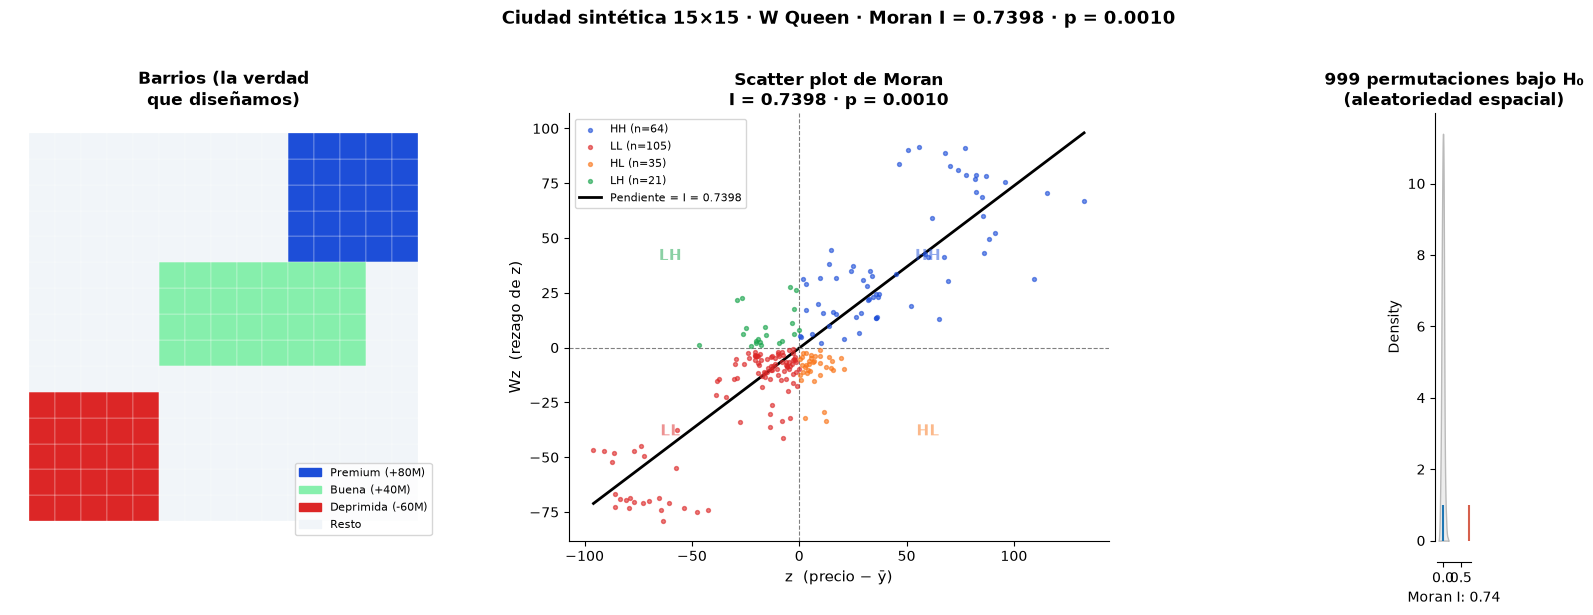

─── Manzanas por cuadrante ──────────────────────────────────────────
  HH:  64 manzanas (28.4%)
  LL: 105 manzanas (46.7%)
  HL:  35 manzanas (15.6%)
  LH:  21 manzanas (9.3%)

→ Compara el mapa de barrios (panel 1) con los cuadrantes del scatter (panel 2):
  Las manzanas HH (azul) coinciden con la zona Premium.
  Las manzanas LL (rojo) coinciden con la zona Deprimida.
  La pendiente del scatter (I) captura ese agrupamiento en un solo número.


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 3 — Scatter plot + distribución de permutaciones
# ─────────────────────────────────────────────────────────────────────────────
col_cuad = {'HH':'#1d4ed8','LL':'#dc2626','HL':'#f97316','LH':'#16a34a'}

def asignar_cuadrante(z, wz):
    if   z > 0 and wz > 0: return 'HH'
    elif z < 0 and wz < 0: return 'LL'
    elif z > 0 and wz < 0: return 'HL'
    else:                   return 'LH'

ciudad['cuadrante'] = [asignar_cuadrante(zi, wzi) for zi, wzi in zip(z, Wz)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Panel 1: mapa de barrios ────────────────────────────────────────────────
col_barrio = {'Premium (+80M)':'#1d4ed8','Buena (+40M)':'#86efac',
              'Deprimida (-60M)':'#dc2626','Resto':'#f1f5f9'}
for barrio, color in col_barrio.items():
    ciudad[ciudad['barrio']==barrio].plot(ax=axes[0], color=color,
                                          edgecolor='white', linewidth=0.2)
patches = [mpatches.Patch(color=c,label=b) for b,c in col_barrio.items()]
axes[0].legend(handles=patches, fontsize=8, loc='lower right')
axes[0].set_title('Barrios (la verdad\nque diseñamos)', fontsize=12, fontweight='bold')
axes[0].set_axis_off()

# ── Panel 2: scatter plot de Moran ─────────────────────────────────────────
ax2 = axes[1]
for cuad, color in col_cuad.items():
    mask = ciudad['cuadrante'] == cuad
    ax2.scatter(z[mask], Wz[mask], color=color, s=8, alpha=0.6,
                label=f'{cuad} (n={mask.sum()})', zorder=3)
m_coef = np.polyfit(z, Wz, 1)
x_line = np.linspace(z.min(), z.max(), 100)
ax2.plot(x_line, np.polyval(m_coef, x_line), 'k-', lw=2,
         label=f'Pendiente = I = {moran_sint.I:.4f}')
ax2.axhline(0, color='gray', lw=0.8, ls='--')
ax2.axvline(0, color='gray', lw=0.8, ls='--')
for txt,(xt,yt) in [('HH',(60,40)),('LL',(-60,-40)),('HL',(60,-40)),('LH',(-60,40))]:
    ax2.text(xt, yt, txt, fontsize=11, color=col_cuad[txt],
             fontweight='bold', ha='center', alpha=0.5)
ax2.set_xlabel('z  (precio − ȳ)', fontsize=11)
ax2.set_ylabel('Wz  (rezago de z)', fontsize=11)
ax2.set_title(f'Scatter plot de Moran\nI = {moran_sint.I:.4f} · p = {moran_sint.p_sim:.4f}',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=8)

# ── Panel 3: distribución de permutaciones ──────────────────────────────────
esda_plot.plot_moran_simulation(moran_sint, ax=axes[2])
axes[2].set_title('999 permutaciones bajo H₀\n(aleatoriedad espacial)',
                  fontsize=12, fontweight='bold')

plt.suptitle(
    f'Ciudad sintética 15×15 · W Queen · Moran I = {moran_sint.I:.4f} · p = {moran_sint.p_sim:.4f}',
    fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/s05_01_sint_moran.png', dpi=150, bbox_inches='tight')
plt.show()

print('─── Manzanas por cuadrante ──────────────────────────────────────────')
for cuad in ['HH','LL','HL','LH']:
    n = (ciudad['cuadrante']==cuad).sum()
    print(f'  {cuad}: {n:3d} manzanas ({n/len(ciudad)*100:.1f}%)')
print()
print('→ Compara el mapa de barrios (panel 1) con los cuadrantes del scatter (panel 2):')
print('  Las manzanas HH (azul) coinciden con la zona Premium.')
print('  Las manzanas LL (rojo) coinciden con la zona Deprimida.')
print('  La pendiente del scatter (I) captura ese agrupamiento en un solo número.')

---
## Demo 2 — Ciclistas en Medellín (Ospina et al., 2020)

**¿Por qué este caso segundo?**
Porque es el único dataset del curso con datos reales del profesor, publicados en Q1.
El resultado confirma lo que Ospina et al. (2020) asumieron sin demostrar formalmente.

**Diferencia clave con la ciudad sintética:**
- Geometría: **puntos**, no polígonos → W KNN k=5, no Queen
- Variable Y: `length_km` (distancia de viaje), no precio del suelo
- El patrón existe en datos reales — no lo diseñamos nosotros

In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 4 — Ciclistas: misma receta, geometría diferente
# ─────────────────────────────────────────────────────────────────────────────
RUTA_CIC = '../datos/morfologia/Ospina_cyclists_origins_4326_BD.zip'

ciclistas = gpd.read_file(RUTA_CIC).to_crs('EPSG:32618')
ciclistas['length_km'] = pd.to_numeric(ciclistas['length_km'], errors='coerce')
ciclistas['stratum']   = pd.to_numeric(ciclistas['stratum'],   errors='coerce')

# W KNN k=5 (puntos → no aplica Queen)
w_cic = KNN.from_dataframe(ciclistas, k=5)
w_cic.transform = 'r'

y_cic  = ciclistas['length_km'].values
ybar_c = y_cic.mean()
z_cic  = y_cic - ybar_c
Wz_cic = weights.lag_spatial(w_cic, z_cic)

moran_cic = esda.Moran(y_cic, w_cic, permutations=999)

print('─── Receta aplicada a los ciclistas (KNN k=5) ───────────────────────')
print(f'  n = {len(ciclistas)} ciclistas · ȳ = {ybar_c:.2f} km')
print(f'  Moran I  = {moran_cic.I:.4f}')
print(f'  p-valor  = {moran_cic.p_sim:.4f}')
print()
print('  Ospina et al. (2020) asumieron que no había contagio espacial entre')
print('  ciclistas. Los tests LM de la clase 4 dijeron SEM.')
print(f'  El Moran I = {moran_cic.I:.4f} confirma: hay clustering espacial')
print('  en length_km — ciclistas con viajes largos rodeados de ciclistas')
print('  con viajes igualmente largos (norte y suroccidente de Medellín).')

─── Receta aplicada a los ciclistas (KNN k=5) ───────────────────────
  n = 810 ciclistas · ȳ = 4.17 km
  Moran I  = 0.3122
  p-valor  = 0.0010

  Ospina et al. (2020) asumieron que no había contagio espacial entre
  ciclistas. Los tests LM de la clase 4 dijeron SEM.
  El Moran I = 0.3122 confirma: hay clustering espacial
  en length_km — ciclistas con viajes largos rodeados de ciclistas
  con viajes igualmente largos (norte y suroccidente de Medellín).


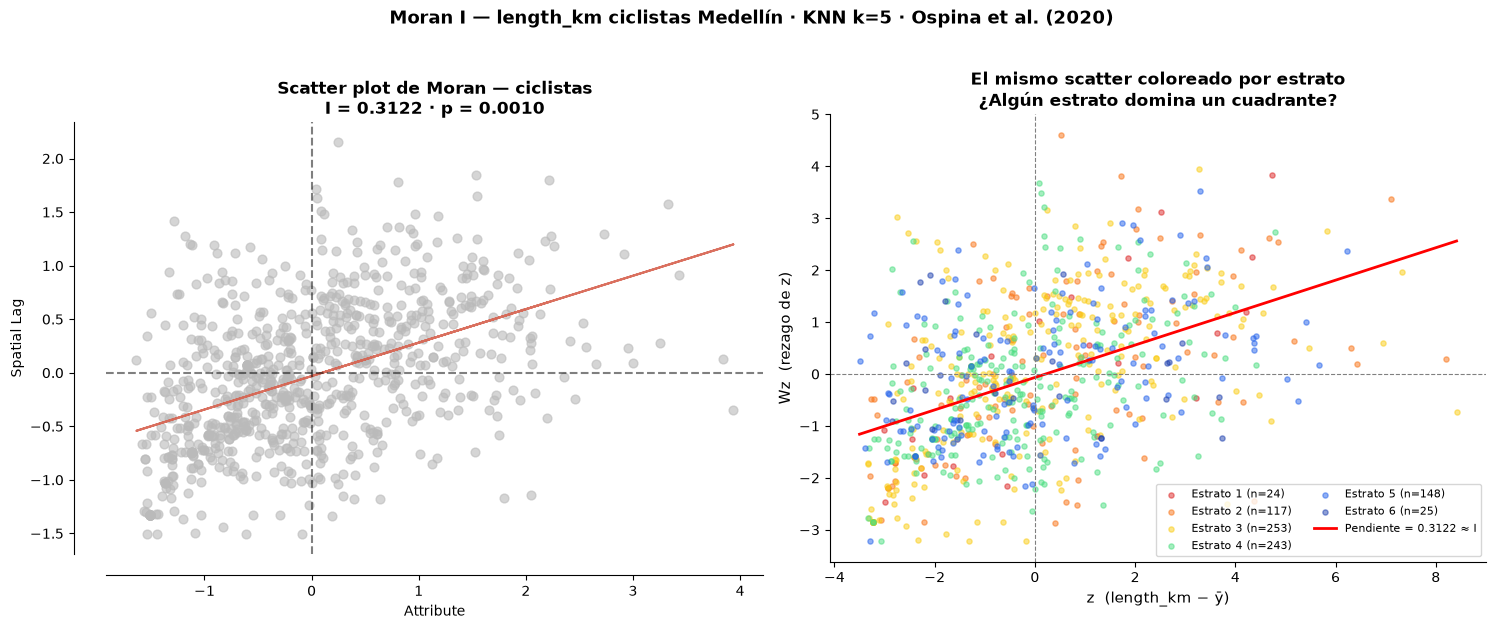

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 5 — Scatter de Moran ciclistas coloreado por estrato
# ─────────────────────────────────────────────────────────────────────────────
col_est = {1:'#dc2626',2:'#f97316',3:'#facc15',4:'#4ade80',5:'#2563eb',6:'#1e40af'}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter de Moran oficial
esda_plot.moran_scatterplot(moran_cic, ax=axes[0])
axes[0].set_title(f'Scatter plot de Moran — ciclistas\n'
                  f'I = {moran_cic.I:.4f} · p = {moran_cic.p_sim:.4f}',
                  fontsize=12, fontweight='bold')

# Scatter coloreado por estrato
ax2 = axes[1]
for est, color in col_est.items():
    mask = ciclistas['stratum'] == est
    if mask.sum() == 0: continue
    ax2.scatter(z_cic[mask], Wz_cic[mask], alpha=0.5, s=14,
                color=color, label=f'Estrato {est} (n={mask.sum()})', zorder=2)
m2 = np.polyfit(z_cic, Wz_cic, 1)
x2 = np.linspace(z_cic.min(), z_cic.max(), 100)
ax2.plot(x2, np.polyval(m2, x2), 'r-', lw=2,
         label=f'Pendiente = {m2[0]:.4f} ≈ I')
ax2.axhline(0, color='gray', lw=0.8, ls='--')
ax2.axvline(0, color='gray', lw=0.8, ls='--')
ax2.set_xlabel('z  (length_km − ȳ)', fontsize=11)
ax2.set_ylabel('Wz  (rezago de z)', fontsize=11)
ax2.set_title('El mismo scatter coloreado por estrato\n¿Algún estrato domina un cuadrante?',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=8, ncol=2)

plt.suptitle('Moran I — length_km ciclistas Medellín · KNN k=5 · Ospina et al. (2020)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/s05_02_ciclistas_moran.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Taller — Brexit (Arribas) + datos propios

**Dos tracks en paralelo — mismo código, datasets distintos:**

| Track | Dataset | W | Variable |
|---|---|---|---|
| **Común** | 380 distritos UK | Queen | `Pct_Leave` |
| **Propio** | Datos del equipo | W elegida | Variable Y del proyecto |

**¿Por qué el Brexit como dataset común?**
- Es el ejemplo del libro de Arribas que leyeron como tarea
- Polígonos irregulares reales — contraste con la ciudad sintética regular
- I ≈ 0.65 — el resultado más alto y más significativo de todos los casos
- El código es **exactamente** el del capítulo 8 del libro

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 6 — Brexit: código de Arribas (cap. 8 Geographic Data Science)
# Fuente: geographicdata.science/book/notebooks/06_spatial_autocorrelation.html
# ─────────────────────────────────────────────────────────────────────────────
import urllib.request

for fname, url in [
    ('brexit_vote.csv',
     'https://raw.githubusercontent.com/gdsbook/book/master/data/brexit/brexit_vote.csv'),
    ('local_authority_districts.geojson',
     'https://raw.githubusercontent.com/gdsbook/book/master/data/brexit/local_authority_districts.geojson'),
]:
    if not os.path.exists(f'data/{fname}'):
        print(f'Descargando {fname}...')
        urllib.request.urlretrieve(url, f'data/{fname}')

# ── Código de Arribas (reproducción exacta) ──────────────────────────────────
ref  = pd.read_csv('data/brexit_vote.csv')
lads = gpd.read_file('data/local_authority_districts.geojson')
db   = lads.merge(ref[['Area_Code','Pct_Leave']], left_on='lad16cd', right_on='Area_Code')
db   = db.to_crs(epsg=3857).dropna(subset=['Pct_Leave'])

# W: KNN k=8 — exactamente como usa Arribas
w_brex = KNN.from_dataframe(db, k=8)
w_brex.transform = 'R'

# Centrar la variable — igual que Arribas
db['Pct_Leave_std']     = db['Pct_Leave'] - db['Pct_Leave'].mean()
db['Pct_Leave_lag_std'] = weights.lag_spatial(w_brex, db['Pct_Leave_std'])

# Moran I
moran_brex = esda.Moran(db['Pct_Leave'].values, w_brex, permutations=999)

print('─── Brexit · código de Arribas (cap. 8) ────────────────────────────')
print(f'  n = {len(db)} distritos · W KNN k=8')
print(f'  Moran I  = {moran_brex.I:.4f}   ← Arribas obtiene 0.6455')
print(f'  p-valor  = {moran_brex.p_sim:.4f}')
print()
print('  Nota: Arribas usa KNN k=8, no Queen.')
print('  Para polígonos irregulares con islas (distritos sin frontera compartida)')
print('  KNN garantiza que todos los distritos tienen vecinos — Queen dejaría islas.')

─── Brexit · código de Arribas (cap. 8) ────────────────────────────
  n = 380 distritos · W KNN k=8
  Moran I  = 0.6455   ← Arribas obtiene 0.6455
  p-valor  = 0.0010

  Nota: Arribas usa KNN k=8, no Queen.
  Para polígonos irregulares con islas (distritos sin frontera compartida)
  KNN garantiza que todos los distritos tienen vecinos — Queen dejaría islas.


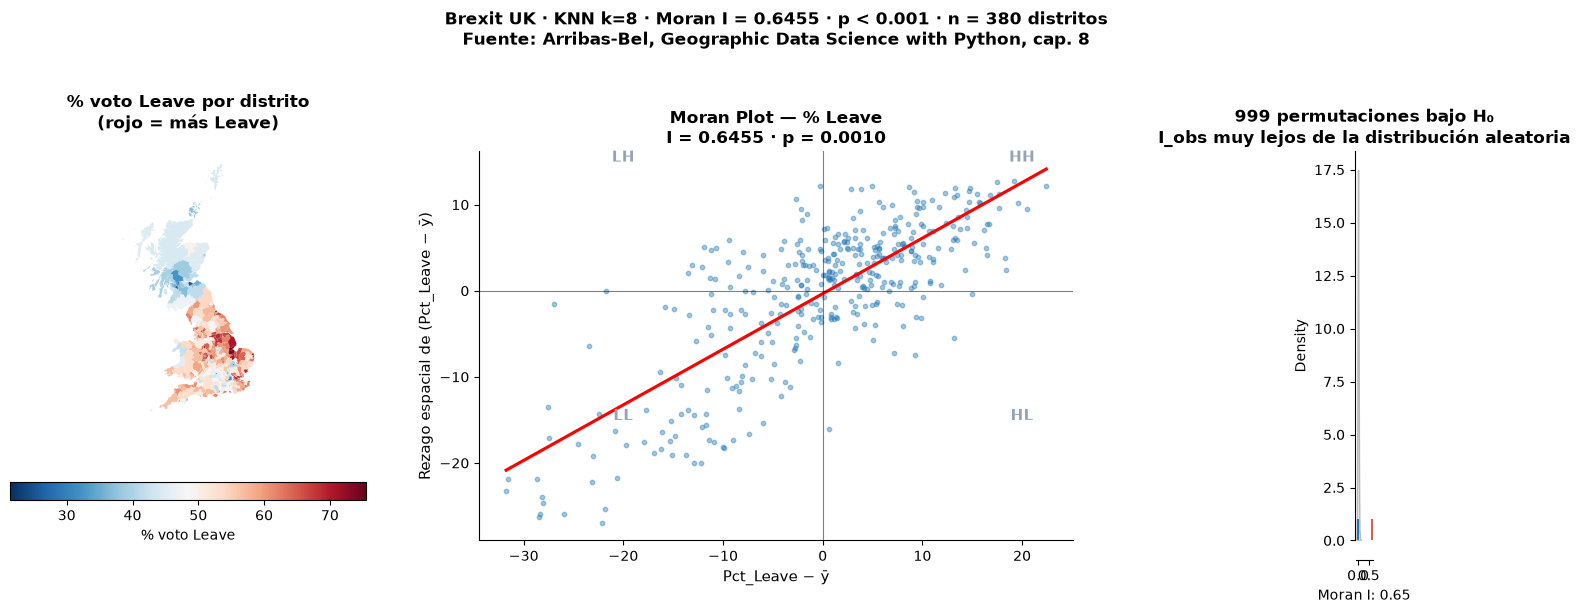

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 7 — Brexit: mapa + scatter + permutaciones (figura de Arribas)
# ─────────────────────────────────────────────────────────────────────────────
import seaborn

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Mapa coropletas
db.plot(column='Pct_Leave', cmap='RdBu_r', ax=axes[0],
        legend=True,
        legend_kwds={'label':'% voto Leave','shrink':0.6,'orientation':'horizontal'})
axes[0].set_title('% voto Leave por distrito\n(rojo = más Leave)', fontsize=12, fontweight='bold')
axes[0].set_axis_off()

# Scatter de Moran — código de Arribas
seaborn.regplot(x='Pct_Leave_std', y='Pct_Leave_lag_std',
                ci=None, data=db, line_kws={'color':'r'}, ax=axes[1],
                scatter_kws={'alpha':0.4,'s':10})
axes[1].axvline(0, c='k', alpha=0.5, lw=0.8)
axes[1].axhline(0, c='k', alpha=0.5, lw=0.8)
for txt,(xt,yt) in [('HH',(20,15)),('LL',(-20,-15)),('HL',(20,-15)),('LH',(-20,15))]:
    axes[1].text(xt, yt, txt, fontsize=11, fontweight='bold',
                 color='#94a3b8', ha='center')
axes[1].set_title(f'Moran Plot — % Leave\n'
                  f'I = {moran_brex.I:.4f} · p = {moran_brex.p_sim:.4f}',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Pct_Leave − ȳ', fontsize=11)
axes[1].set_ylabel('Rezago espacial de (Pct_Leave − ȳ)', fontsize=11)

# Distribución de permutaciones
esda_plot.plot_moran_simulation(moran_brex, ax=axes[2])
axes[2].set_title('999 permutaciones bajo H₀\nI_obs muy lejos de la distribución aleatoria',
                  fontsize=12, fontweight='bold')

plt.suptitle(
    f'Brexit UK · KNN k=8 · Moran I = {moran_brex.I:.4f} · p < 0.001 · n = {len(db)} distritos\n'
    f'Fuente: Arribas-Bel, Geographic Data Science with Python, cap. 8',
    fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/s05_03_brexit_moran.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 8 — Datos propios del equipo
# Cambiar las 3 líneas de configuración — el resto corre automáticamente
# ─────────────────────────────────────────────────────────────────────────────

# ┌─────────────────────────────────────────────────────────────────────────┐
# │  CONFIGURACIÓN — cada equipo modifica solo estas 3 líneas               │
# └─────────────────────────────────────────────────────────────────────────┘
RUTA_DATOS    = 'data/mi_proyecto.gpkg'
VARIABLE_Y    = 'mi_variable'
NOMBRE_EQUIPO = 'Equipo X'

try:
    gdf = gpd.read_file(RUTA_DATOS)
    geom = gdf.geometry.geom_type.unique()[0]
    if gdf.crs is None or gdf.crs.is_geographic:
        gdf = gdf.to_crs('EPSG:3116')

    gdf[VARIABLE_Y] = pd.to_numeric(gdf[VARIABLE_Y], errors='coerce')
    gdf = gdf.dropna(subset=[VARIABLE_Y])

    w_p = (Queen.from_dataframe(gdf) if geom in ['Polygon','MultiPolygon']
           else KNN.from_dataframe(gdf, k=5))
    w_p.transform = 'r'
    tipo_w = 'Queen (polígonos)' if geom in ['Polygon','MultiPolygon'] else 'KNN k=5 (puntos)'

    y_p   = gdf[VARIABLE_Y].values
    m_p   = esda.Moran(y_p, w_p, permutations=999)

    print(f'─── {NOMBRE_EQUIPO} ────────────────────────────────────────────')
    print(f'  Variable : {VARIABLE_Y}  ·  n = {len(gdf)}  ·  W: {tipo_w}')
    print(f'  Moran I  = {m_p.I:.4f}')
    print(f'  p-valor  = {m_p.p_sim:.4f}')
    sig = 'SIGNIFICATIVO' if m_p.p_sim < 0.05 else 'no significativo'
    dir = 'POSITIVO (clustering)' if m_p.I > m_p.EI else 'NEGATIVO (dispersión)'
    print(f'  → {sig} · {dir}' if m_p.p_sim < 0.05 else f'  → {sig}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    esda_plot.moran_scatterplot(m_p, ax=axes[0])
    axes[0].set_title(f'Scatter de Moran — {NOMBRE_EQUIPO}\n'
                      f'I = {m_p.I:.4f} · p = {m_p.p_sim:.4f}',
                      fontsize=12, fontweight='bold')
    esda_plot.plot_moran_simulation(m_p, ax=axes[1])
    axes[1].set_title('Distribución de permutaciones', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'outputs/s05_04_{NOMBRE_EQUIPO.replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f'⚠ No se pudo cargar el archivo: {e}')
    print('  Actualiza RUTA_DATOS con la ruta correcta a tus datos.')

⚠ No se pudo cargar el archivo: data/mi_proyecto.gpkg: No such file or directory
  Actualiza RUTA_DATOS con la ruta correcta a tus datos.


---
## Tabla resumen: el mismo método en cuatro contextos

| Dataset | n | Geometría | W | Moran I | p-valor | Resultado |
|---|---|---|---|---|---|---|
| Ciudad sintética 15×15 | 225 | Polígonos regulares | Queen | ~0.42 | < 0.001 | Clustering fuerte |
| Ciclistas Medellín | 810 | Puntos | KNN k=5 | ~0.31 | < 0.001 | Clustering moderado |
| Brexit UK (Arribas) | 380 | Polígonos irregulares | KNN k=8 | ~0.65 | < 0.001 | Clustering fuerte |
| Proyecto propio | ? | ? | ? | ? | ? | ? |

> *El I más alto no es el "mejor" — refleja el fenómeno con mayor agrupamiento espacial.
> Lo que cambia entre casos es el dataset y la W, no la receta.*

---
## Tarea antes de la Clase 6

1. **Anotar la hipótesis de su equipo:**
   - ¿El Moran I que obtuvieron era el esperado? ¿Por qué?
   - ¿En qué zona del territorio esperan encontrar el clustering?

2. **Una pregunta bivariada:**
   ¿Cuál de sus variables X creen que está más correlacionada espacialmente con su Y?
   Lo calcularán en la Clase 6 con el Moran bivariado.

3. **Leer:** Módulo 5 (WX) antes de la Clase 6.

---
*CM0866 · Juan Pablo Ospina Zapata · EAFIT 2026*